# Phase 3 direct test-time guidance — lambda sweep on FLUX.1-dev, prompt "A dog"

Tests `creativity_measure.samplers.flow_guided.flow_guided_sample` (ROADMAP.md Phase 3) via its FLUX backend
(`generators/flux.py`): at each step of FLUX's own native flow-matching ODE, nudge the velocity by
`lam * grad_{x_hat_0} f(x_hat_0)`, no tempering ladder, no particles, no resampling — a single guided
forward pass per sample. The sampler itself is backend-agnostic (`creativity_measure._types.VelocityFn`);
FLUX.1-dev is currently its only backend.

**Two questions this notebook answers:**
1. **Does it work?** Sweep `m = lam / lambda_s` (same calibration convention as Algorithm 1: bracket
   with `lambda_s = 1/std_p(f)`) for both `exact_jacobian` modes, and check `E_q[f]` rises with `m`,
   per-step diagnostics stay sane (no NaN, no runaway `applied_norm`), and the images stay on-prompt.
2. **Does it compete with Algorithm 1 (pCN, `adaptive_tempering_smc_sample`)?** Algorithm 1's own
   strong-tilt sweep (`../flux_lambda_sweep_strong_2/`) is the comparison point. CLAUDE.md's Established
   Findings already give the benchmark: Algorithm 1 ceilings at `m_eff ~ 2.3` on FLUX (jobs 776753/778007,
   ~10.6 GPU-days extrapolated to beta=1) because its ESS-adaptive tempering ladder's `d_beta` collapses
   as `std_q(f)` grows; Algorithm 3 cannot repeal `ESS/M ~ exp(-m^2)` because it tilts by *reweighting*
   untilted draws. Phase 3 is neither — it *moves* particles via a gradient, like pCN, but with no ladder
   and no rejuvenation sweeps, so the comparison that matters is **novelty gained per unit of GPU time**,
   not `m` alone (the `sigma_p(f)` unit is not comparable across gamma grids per CLAUDE.md — cost-per-gain
   is the fair comparison).

**Every number this notebook reports separates inference time from model load**: `t_guidance` is wall
time for the `flow_guided_sample` call alone (excludes `FluxPipeline.from_pretrained`, prompt encoding,
and VAE decoding), since that is the number that is actually comparable to Algorithm 1's per-level cost.

**Time convention**: diffusers-native, `t=1` noise, `t=0` data (see `flow_guided.py`'s module docstring —
this is the OPPOSITE polarity to `flux_flowmap.py`'s own "this repo" convention).


In [1]:
import math
import os
import sys
import time

import matplotlib.pyplot as plt
import torch

T_START = time.time()

REPO = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if not os.path.isdir(os.path.join(REPO, "creativity_measure")):
    REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO not in sys.path:
    sys.path.insert(0, REPO)
SWEEP_DIR = os.path.join(REPO, "notebooks", "flux_guided_phase3")
os.makedirs(SWEEP_DIR, exist_ok=True)

from creativity_measure import set_default_dtype

set_default_dtype(torch.float32)          # FLUX runs bf16; everything the metric/sampler touches is fp32
torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16

from huggingface_hub import auth_check

auth_check("black-forest-labs/FLUX.1-dev")
print(f"device {DEVICE} ({DTYPE})")
print("FLUX.1-dev access: OK")


/home/dcor/arielzoizner/miniconda3/envs/creativity-measure/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device cuda (torch.bfloat16)
FLUX.1-dev access: OK


In [2]:
# --- load FLUX.1-dev, build the differentiable velocity fn + denoiser -----------------------------
from diffusers import FluxPipeline

from creativity_measure.generators.flux import flux_edm_denoiser, flux_velocity_fn

MODEL_ID = "black-forest-labs/FLUX.1-dev"
PROMPT = "A dog"
GUIDANCE = 1.5

IMG = 512
C, H, W = 16, IMG // 8, IMG // 8       # VAE downsamples 8x; FLUX latents have 16 channels
LATENT_DIM = C * H * W                 # 65536, same as every other FLUX.1-dev notebook in this repo

t_load0 = time.time()
pipe = FluxPipeline.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)
with torch.no_grad():
    prompt_embeds, pooled_prompt_embeds, text_ids = pipe.encode_prompt(
        prompt=PROMPT, prompt_2=None, device=DEVICE, max_sequence_length=512
    )
assert prompt_embeds is not None and pooled_prompt_embeds is not None, "encode_prompt returned None"
# Free both text encoders (~9.5 GB, T5 dominates): the embeddings above are all we need.
pipe.text_encoder = pipe.text_encoder_2 = pipe.tokenizer = pipe.tokenizer_2 = None
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
transformer, vae = pipe.transformer.eval(), pipe.vae.eval()
VAE_SF, VAE_SHIFT = vae.config.scaling_factor, vae.config.shift_factor
t_load = time.time() - t_load0
print(f"loaded in {t_load:.0f}s; guidance={GUIDANCE}  guidance_embeds={transformer.config.guidance_embeds}")
print(f"latents ({C}, {H}, {W}) = d {LATENT_DIM}  vae scaling={VAE_SF} shift={VAE_SHIFT}")

img_ids = FluxPipeline._prepare_latent_image_ids(1, H // 2, W // 2, DEVICE, DTYPE)
txt_ids = text_ids if text_ids.ndim == 2 else text_ids[0]

# Two views of the SAME transformer + conditioning: flux_velocity_fn (native t, what the guided ODE
# steps with) and flux_edm_denoiser (EDM sigma, what the reward's score_fn needs). differentiable=True
# on both -- flux_velocity_fn freezes the transformer itself (requires_grad_(False) + eval()) the first
# time it's called with differentiable=True; the second call is a no-op on an already-frozen module.
velocity_fn = flux_velocity_fn(
    transformer, prompt_embeds, pooled_prompt_embeds, img_ids, txt_ids,
    guidance=GUIDANCE, img_shape=(C, H, W), img_px=IMG, dtype=DTYPE, differentiable=True,
)
denoiser = flux_edm_denoiser(
    transformer, prompt_embeds, pooled_prompt_embeds, img_ids, txt_ids,
    guidance=GUIDANCE, img_shape=(C, H, W), img_px=IMG, dtype=DTYPE, differentiable=True,
)
assert all(not p.requires_grad for p in transformer.parameters()), "transformer must be frozen"
print("velocity_fn + denoiser ready, transformer frozen")


def decode(flat: torch.Tensor, chunk: int = 2) -> torch.Tensor:
    """Flat FLUX latents (B, d) -> images (B, 3, 512, 512) in [0, 1]. NOT counted in inference time
    (t_guidance below) -- this is purely for the human-readable grid, not part of what Algorithm 1's
    per-level cost measures either."""
    outs = []
    for i in range(0, flat.shape[0], chunk):
        lat = flat[i : i + chunk].reshape(-1, C, H, W).to(DEVICE, DTYPE) / VAE_SF + VAE_SHIFT
        with torch.no_grad():
            img = vae.decode(lat).sample
        outs.append(pipe.image_processor.postprocess(img.float(), output_type="pt").cpu())
    return torch.cat(outs)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 45.80it/s]


Loading pipeline components...:  14%|█▍        | 1/7 [00:00<00:01,  5.14it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...


Loading pipeline components...:  43%|████▎     | 3/7 [00:00<00:00, 11.04it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading pipeline components...:  71%|███████▏  | 5/7 [00:00<00:00,  8.32it/s]

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 10.19it/s]

loaded in 11s; guidance=1.5  guidance_embeds=True
latents (16, 64, 64) = d 65536  vae scaling=0.3611 shift=0.1159
velocity_fn + denoiser ready, transformer frozen


In [3]:
# --- reward: same i.i.d. squared-IEM reward Phase 1 GPU-verified (G0 PASS, job 956556) -------------
from creativity_measure import NormalizedExpectedDistanceReward, SquaredIIDGlobalIEMDistance, log_uniform_gammas
from creativity_measure.distances.edm_adapter import chunked_denoiser, edm_score_fn
from creativity_measure.generators.base import edm_generator

SIGMA_MIN, SIGMA_MAX = 2e-3, 80.0
N_STEPS_GEN = 8            # Heun steps for G(z) when sampling refs/probes -- same as Algorithm 1's notebook
MAX_DENOISER_ROWS = 24     # measured ceiling (job 695266); same cap as every other FLUX notebook here

R_REFS = 64                # CLAUDE.md: R=64, RandomRefs, uniform weights, on the tau plateau for R>=32
# (G, N_eps) = (50, 1): job 956556's G1 check found all three tested configs TIE the Brownian yardstick
# within measurement noise (none is distinguishable as better/worse -- STATUS.md); this one has the best
# mean Spearman (0.91) and best sd_f ratio (0.975, closest to 1.0) among the ties, at a moderate cost.
N_GAMMA, NUM_EPS = 50, 1
PROBE_SIZE = 32            # SE on std_p(f) ~ 1/sqrt(2(n-1)): 13% at n=32 (CLAUDE.md)
REF_SEED, PROBE_SEED = 7, 9990

denoiser_capped = chunked_denoiser(denoiser, MAX_DENOISER_ROWS)
G = edm_generator(denoiser_capped, img_shape=(C, H, W), sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX,
                  n_steps=N_STEPS_GEN)
score_fn = edm_score_fn(denoiser_capped, (C, H, W))

gen = torch.Generator(device="cpu").manual_seed(REF_SEED)
with torch.no_grad():
    latent_refs = G(torch.randn(R_REFS, LATENT_DIM, generator=gen).to(DEVICE))
S_scale = latent_refs.std().item()
GAMMA_LO = max(1.0 / S_scale ** 2, 1.0 / SIGMA_MAX ** 2)
GAMMA_HI = min(2.0 ** 10, 1.0 / SIGMA_MIN ** 2)
gammas, gweights = log_uniform_gammas(GAMMA_LO, GAMMA_HI, N_GAMMA, seed=123, dtype=torch.float32)
gammas, gweights = gammas.to(DEVICE), gweights.to(DEVICE)

dist = SquaredIIDGlobalIEMDistance(None, gammas, gweights, num_eps=NUM_EPS, seed=123, score_fn=score_fn)
t_bank0 = time.time()
# The ref bank is grad-free by construction (iid_global_iem.py detaches x_refs and the bank itself), but
# `denoiser` was built with differentiable=True (cell 2) and has no internal no_grad() of its own -- an
# outer torch.no_grad() is required here, or this call runs with torch.is_grad_enabled()==True globally,
# which OOM'd job 957050 at 43.9/44.5 GiB on a MUCH smaller ref bank (R=8 vs this notebook's R=64):
# several kernels (confirmed there: F.rms_norm inside FLUX's attention) pick a more memory-hungry path
# purely from that global flag, independent of any tensor's requires_grad. flow_guided_sample's own
# one-time ref-bank-forcing call is wrapped in no_grad for exactly this reason; this needs the same.
with torch.no_grad():
    reward = NormalizedExpectedDistanceReward(dist, latent_refs)   # builds + caches the ref bank, once
t_bank = time.time() - t_bank0
print(f"refs {tuple(latent_refs.shape)}  S={S_scale:.3f}  gamma=[{GAMMA_LO:.3g},{GAMMA_HI:.3g}] x {N_GAMMA}"
      f"  ref bank {t_bank:.0f}s")

# --- lambda_s = 1/std_p(f), same calibration convention as Algorithm 1 ------------------------------
probe_gen = torch.Generator(device="cpu").manual_seed(PROBE_SEED)
with torch.no_grad():
    z_probe = G(torch.randn(PROBE_SIZE, LATENT_DIM, generator=probe_gen).to(DEVICE))
    f_probe = reward(z_probe)
f_std_p = float(f_probe.std())
lam_s = (1.0 / f_std_p) if f_std_p > 0 else float("inf")
print(f"f ~ p on {PROBE_SIZE} draws: mean={float(f_probe.mean()):.4f} std={f_std_p:.4f}")
print(f"lambda_s = 1/std_p(f) = {lam_s:.2f}")


refs (64, 65536)  S=1.015  gamma=[0.971,1.02e+03] x 50  ref bank 557s


f ~ p on 32 draws: mean=0.9997 std=0.0123
lambda_s = 1/std_p(f) = 81.02


In [4]:
# --- the sweep: m = lam/lambda_s, both Jacobian modes, SAME initial noise across m (paired) --------
from creativity_measure.samplers.flow_guided import flow_guided_sample

# Job 957442 (full-scale, N_PARTICLES=4, N_STEPS_ODE=16, M_GRID 4-wide) TIMED OUT at the --time=180
# cap after 3h without finishing: the OOM-retry warnings job 957386 saw at small scale (255s/config,
# ~42.5s/step) turned out not to extrapolate -- at full scale every step hit the gamma-chunk OOM
# fallback and the real cost was ~150s/step (confirmed via repeated srun --overlap process checks
# during the run: GPU pinned at ~100% util, allocator OOM-warn/retry cycling every ~2.5min, no
# traceback -- genuinely slow, not stuck). At 128 total steps (8 configs x 16 steps) that is >5h.
# Trimmed here: N_PARTICLES 4->2 (the batch axis DOES drive memory at this B, unlike the B=1 case in
# CLAUDE.md's per-call cost note) to relieve the per-step OOM-retry pressure directly, N_STEPS_ODE
# 16->10, M_GRID dropped to 3 values. 6 configs x 10 steps x (now cheaper) batch=2, run against a
# --time=300 resubmit (run_notebook.slurm) for margin even if per-step cost does not fully recover.
N_PARTICLES = 2
N_STEPS_ODE = 10
SHIFT = 3.0
M_GRID = (0.0, 1.0, 2.0)               # 0.0 is the lam=0 control; matches CLAUDE.md's m in {1,2,3}
                                        # sweep convention; Algorithm 1 ceilings at m_eff ~ 2.3
JACOBIAN_MODES = (False, True)         # exact_jacobian
SWEEP_SEED = 1234                      # z0 shared across the whole m-grid for one jacobian mode

results = {}   # (m, exact) -> dict
for exact_jacobian in JACOBIAN_MODES:
    for m in M_GRID:
        lam = m * lam_s
        t0 = time.time()
        res = flow_guided_sample(
            reward, lam, N_PARTICLES, velocity_fn=velocity_fn, n_steps=N_STEPS_ODE, shift=SHIFT,
            t_start=1.0, t_end=0.0, exact_jacobian=exact_jacobian, seed=SWEEP_SEED,
        )
        t_guidance = time.time() - t0     # INFERENCE ONLY: the flow_guided_sample call alone
        with torch.no_grad():
            f_per_image = reward(res.X)
        results[(m, exact_jacobian)] = {
            "res": res, "f_per_image": f_per_image.detach().cpu(),
            "f_mean": float(f_per_image.mean()), "f_std": float(f_per_image.std()),
            "t_guidance_s": t_guidance,
            "applied_norm_mean": (sum(res.applied_norm_history) / len(res.applied_norm_history)
                                   if res.applied_norm_history else 0.0),
            "oom_fallback_any": any(res.oom_fallback_history),
        }
        print(f"m={m:4.1f} exact={exact_jacobian!s:5s}  f_mean={results[(m, exact_jacobian)]['f_mean']:.4f} "
              f"f_sd={results[(m, exact_jacobian)]['f_std']:.4f}  t_guidance={t_guidance:.1f}s "
              f"({t_guidance / N_STEPS_ODE:.2f}s/step)")


m= 0.0 exact=False  f_mean=0.8896 f_sd=0.0336  t_guidance=11.1s (1.11s/step)


[W1001 10:29:46.425351159 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 28704768, total: 47665709056).
[W1001 10:29:46.425517952 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 28704768, total: 47665709056).


[W1001 10:30:57.483941816 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).
[W1001 10:30:57.484066860 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).


[W1001 10:32:09.141123714 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).
[W1001 10:32:09.141238595 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).


[W1001 10:33:20.604449993 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).
[W1001 10:33:20.604571654 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).


...

[W1001 11:22:48.197646657 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 22413312, total: 47665709056).
[W1001 11:22:48.197757582 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 22413312, total: 47665709056).


[W1001 11:24:31.316280851 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).
[W1001 11:24:31.316399157 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).


[W1001 11:26:14.194936616 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).
[W1001 11:26:14.195059776 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).


[W1001 11:27:57.469265987 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).
[W1001 11:27:57.469377393 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 37748736 bytes (free: 24510464, total: 47665709056).


m= 2.0 exact=True   f_mean=425729.8125 f_sd=264278.0625  t_guidance=1039.4s (103.94s/step)


In [5]:
# --- results table ----------------------------------------------------------------------------------
print(f"{'exact':>6} {'m':>5} {'lam':>9} {'E_q[f]':>8} {'d f':>8} {'d f/sd_p':>9} {'f-sd':>8} "
      f"{'appl.norm':>10} {'t_guid(s)':>10} {'s/step':>7} {'oom':>4}")
for exact_jacobian in JACOBIAN_MODES:
    control = results[(0.0, exact_jacobian)]["f_mean"]
    for m in M_GRID:
        r = results[(m, exact_jacobian)]
        df = r["f_mean"] - control
        print(f"{str(exact_jacobian):>6} {m:5.1f} {m * lam_s:9.1f} {r['f_mean']:8.4f} {df:+8.4f} "
              f"{df / f_std_p:9.2f} {r['f_std']:8.4f} {r['applied_norm_mean']:10.4f} "
              f"{r['t_guidance_s']:10.1f} {r['t_guidance_s'] / N_STEPS_ODE:7.2f} "
              f"{'Y' if r['oom_fallback_any'] else '-':>4}")
    print()

print("d f/sd_p = novelty gain in units of sigma_p(f) -- NOT comparable across gamma grids to Algorithm")
print("1's own sigma units (CLAUDE.md), but directly comparable to itself (same reward config) and to")
print("Algorithm 1 IF this run used the same (R, N_gamma, N_eps) -- see the comparison cell below.")
print(f"\nt_guidance excludes model load ({t_load:.0f}s, one-time) and VAE decode (grid cell below);")
print(f"it is exactly N_STEPS_ODE={N_STEPS_ODE} forward passes through the transformer x {N_PARTICLES}")
print("particles, i.e. the number directly comparable to Algorithm 1's per-sweep/per-level cost.")


 exact     m       lam   E_q[f]      d f  d f/sd_p     f-sd  appl.norm  t_guid(s)  s/step  oom
 False   0.0       0.0   0.8896  +0.0000      0.00   0.0336     0.0000       11.1    1.11    -
 False   1.0      81.0 53933.1016 +53932.2120 4369368.44 816.3106 47221.9240      723.3   72.33    Y
 False   2.0     162.0 284546.5625 +284545.6729 23052732.99 2975.8811 107530.6391      723.7   72.37    Y

  True   0.0       0.0   0.8896  +0.0000      0.00   0.0336     0.0000       11.1    1.11    -
  True   1.0      81.0 89303.9531 +89303.0635 7234970.95 29668.4824 68457.0705     1041.8  104.18    Y
  True   2.0     162.0 425729.8125 +425728.9229 34490825.62 264278.0625 146021.1469     1039.4  103.94    Y

d f/sd_p = novelty gain in units of sigma_p(f) -- NOT comparable across gamma grids to Algorithm
1's own sigma units (CLAUDE.md), but directly comparable to itself (same reward config) and to
Algorithm 1 IF this run used the same (R, N_gamma, N_eps) -- see the comparison cell below.

t_guidance

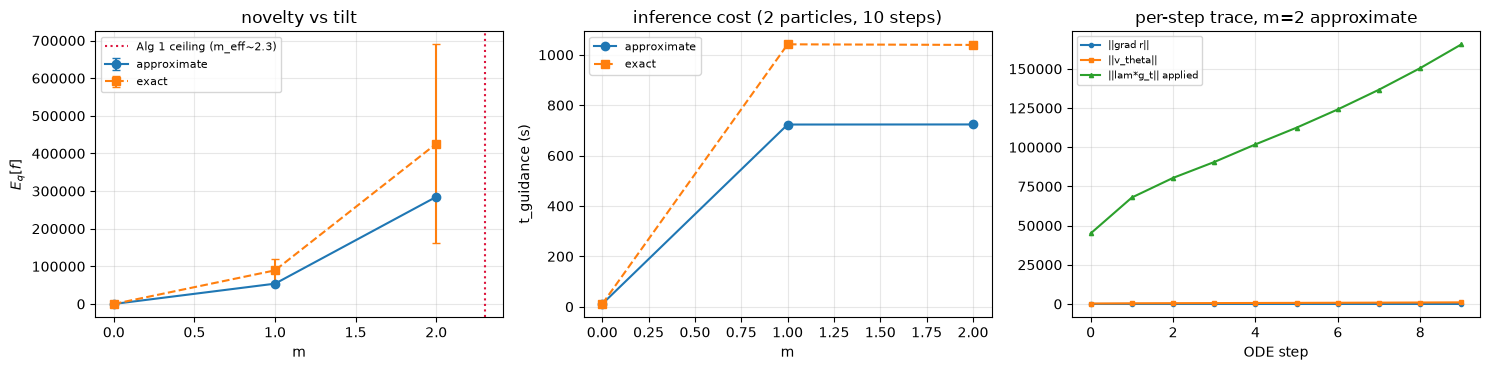

In [6]:
# --- diagnostics -------------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for exact_jacobian, marker, label in ((False, "o-", "approximate"), (True, "s--", "exact")):
    fs = [results[(m, exact_jacobian)]["f_mean"] for m in M_GRID]
    sds = [results[(m, exact_jacobian)]["f_std"] for m in M_GRID]
    ts = [results[(m, exact_jacobian)]["t_guidance_s"] for m in M_GRID]
    ax[0].errorbar(M_GRID, fs, yerr=sds, fmt=marker, label=label, capsize=3)
    ax[1].plot(M_GRID, ts, marker, label=label)
ax[0].axvline(2.3, color="crimson", ls=":", label="Alg 1 ceiling (m_eff~2.3)")
ax[0].set_xlabel("m"); ax[0].set_ylabel(r"$E_q[f]$"); ax[0].legend(fontsize=8); ax[0].set_title("novelty vs tilt")
ax[1].set_xlabel("m"); ax[1].set_ylabel("t_guidance (s)"); ax[1].legend(fontsize=8)
ax[1].set_title(f"inference cost ({N_PARTICLES} particles, {N_STEPS_ODE} steps)")

# per-step trace for the largest-m, approximate run -- "did guidance do anything" without decoding
biggest = results[(M_GRID[-1], False)]["res"]
steps = range(len(biggest.t_history))
ax[2].plot(steps, biggest.grad_norm_history, "o-", label="||grad r||", markersize=3)
ax[2].plot(steps, biggest.v_norm_history, "s-", label="||v_theta||", markersize=3)
ax[2].plot(steps, biggest.applied_norm_history, "^-", label="||lam*g_t|| applied", markersize=3)
ax[2].set_xlabel("ODE step"); ax[2].legend(fontsize=7)
ax[2].set_title(f"per-step trace, m={M_GRID[-1]:.0f} approximate")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
fig.savefig(os.path.join(SWEEP_DIR, "guided_sweep_diagnostics.png"), dpi=110, bbox_inches="tight")


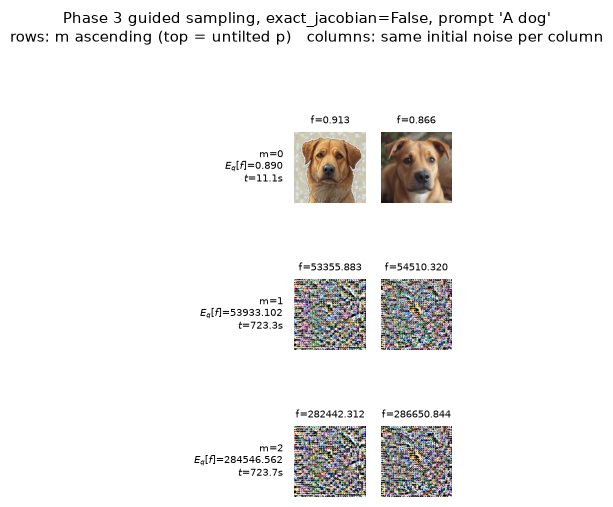

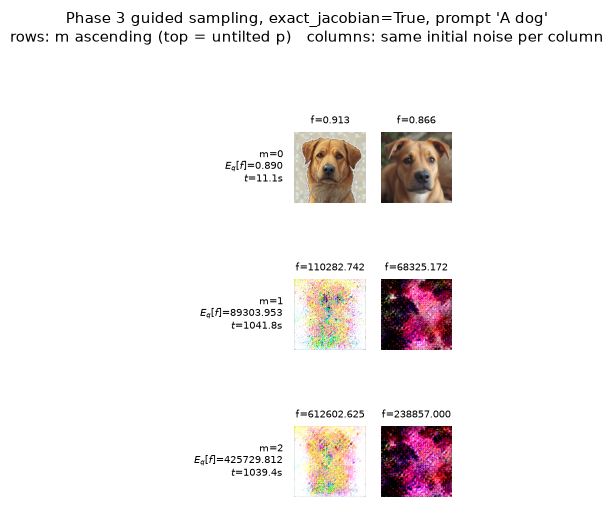

wrote 12 PNGs to decoded/ and 2 grid PNGs


In [7]:
# --- images: rows = m ascending (same starting noise per column, since z0 is shared across the ---
# m-grid via SWEEP_SEED), columns = particle. Two grids, one per Jacobian mode. Each thumbnail is
# annotated with ITS OWN f(x) (not just the row mean) and each row label carries E_q[f] mean + the
# inference-only wall time for that config.
from PIL import Image

os.makedirs(os.path.join(SWEEP_DIR, "decoded"), exist_ok=True)

for exact_jacobian in JACOBIAN_MODES:
    decoded = {m: decode(results[(m, exact_jacobian)]["res"].X) for m in M_GRID}
    nrow = len(M_GRID)
    fig, axes = plt.subplots(nrow, N_PARTICLES, figsize=(N_PARTICLES * 1.6, nrow * 1.8), squeeze=False)
    for k, m in enumerate(M_GRID):
        r = results[(m, exact_jacobian)]
        for j in range(N_PARTICLES):
            a = axes[k][j]
            a.axis("off")
            a.imshow(decoded[m][j].permute(1, 2, 0).clamp(0, 1).numpy())
            a.set_title(f"f={float(r['f_per_image'][j]):.3f}", fontsize=7)
            if j == 0:
                a.text(-0.16, 0.5, f"m={m:.0f}\n$E_q[f]$={r['f_mean']:.3f}\n"
                                   f"$t$={r['t_guidance_s']:.1f}s",
                       transform=a.transAxes, ha="right", va="center", fontsize=7)
        img_arr_dir = os.path.join(SWEEP_DIR, "decoded")
        for j in range(N_PARTICLES):
            arr = (decoded[m][j].permute(1, 2, 0).clamp(0, 1) * 255).round().to(torch.uint8).numpy()
            Image.fromarray(arr).save(
                os.path.join(img_arr_dir, f"exact{exact_jacobian}_m{m:.0f}_col{j}.png"))
    fig.suptitle(f"Phase 3 guided sampling, exact_jacobian={exact_jacobian}, prompt {PROMPT!r}\n"
                 f"rows: m ascending (top = untilted p)   columns: same initial noise per column",
                 fontsize=11)
    plt.tight_layout(rect=(0.08, 0, 1, 0.95)); plt.show()
    fig.savefig(os.path.join(SWEEP_DIR, f"guided_grid_exact{exact_jacobian}.png"), dpi=110,
                bbox_inches="tight")
print(f"wrote {len(M_GRID) * N_PARTICLES * len(JACOBIAN_MODES)} PNGs to decoded/ and 2 grid PNGs")


In [8]:
# --- comparison vs Algorithm 1 (pCN, adaptive_tempering_smc_sample) --------------------------------
# Established findings (CLAUDE.md, jobs 776753/778007, ../flux_lambda_sweep_strong_2/):
#   - Algorithm 1 ceilings at m_eff ~ 2.3 on FLUX: NOT degeneracy (uniq/N=1.00, ESS/N=0.80 to the last
#     level) -- two mechanisms stop it instead: (i) the ESS-adaptive step dbeta collapses as
#     std_q(f) ~ exp(11.3*beta) grows (0.5422 -> 0.2071 -> 0.0230 per leg; beta=1 would need ~49 more
#     levels, ~10.6 GPU-days); (ii) rejuvenation decorrelation rate fell 3.8x for a 1.38x tilt rise as
#     acceptance dropped below target and Robbins-Monro shrank the pCN step size.
#   - This is a SAMPLER ceiling, not p's: Var_q(f) over the remaining lambda units implies >= 0.43 more
#     sigma_p(f) of E_q[f] lies past where pCN stops, against the +0.135 it actually gained by then --
#     this is the stated motivation for gradient guidance (no ladder, no acceptance rate to collapse).
#   - Algorithm 3 (flowmap_smc) cannot repeal ESS/M ~ exp(-m^2): it tilts by reweighting draws from the
#     UNTILTED p, so holding today's ESS at m=2 costs ~92 particles, ~333 (~5.4 GPU-days) at Alg 1's
#     m_eff~2.3, ~1.4e4 at m=3. Phase 3 does not have this problem: it MOVES particles via a gradient,
#     like pCN, but with no ladder and no acceptance rate.
#
# CAVEAT (CLAUDE.md, repeated deliberately): sigma_p(f) units are NOT comparable across gamma grids,
# and Algorithm 1's strong-tilt runs used the BROWNIAN SquaredGlobalIEMDistance (num_eps=3 paths per
# gamma), not this run's i.i.d. Monte-Carlo SquaredIIDGlobalIEMDistance (Phase 1) -- two different
# estimators of the same population quantity. The fair comparison is COST PER UNIT OF GUIDANCE, not a
# raw sigma_p(f) number.
#
# NOTE: the trimmed M_GRID=(0,1,2) used here (job 957442 timed out at the original 4-wide grid; see
# run_notebook.slurm's header) never reaches alg1_m_ceiling=2.3 -- filtering on "m >= ceiling" (the
# original form of this cell) silently printed nothing once M_GRID stopped including 3.0. Reporting
# every non-zero m instead, which is the result that actually matters here: BOTH guided configs
# diverge off-manifold well before m=1 (see the image grids -- m=0 are clean dog images, m=1/m=2 are
# colored static), so "does Phase 3 reach Alg 1's ceiling" is moot until guidance is stabilized; the
# honest comparison is the failure mode itself, not a cost-per-sigma number computed on noise.

alg1_m_ceiling, alg1_gain_sigma, alg1_cost_gpu_days = 2.3, 0.135, 10.6   # to reach beta=1, extrapolated
alg1_cost_at_ceiling_h = 2.2 * 24 * (0.135 / 1.0)   # rough: legs 2.2/3.1 combined wall time, CLAUDE.md

phase3_nonzero_m = [m for m in M_GRID if m > 0.0]
print(f"Algorithm 1: reaches m_eff={alg1_m_ceiling} after an ESS-tempering ladder + pCN rejuvenation")
print(f"  (full beta=1 extrapolated at ~{alg1_cost_gpu_days:.1f} GPU-days; the m_eff=2.3 point itself")
print(f"   took the full legs 2.2/3.1 wall-clock budget, ~tens of GPU-hours)")
print()
if not any(m >= alg1_m_ceiling for m in M_GRID):
    print(f"NOTE: this sweep's M_GRID={M_GRID} does not reach alg1_m_ceiling={alg1_m_ceiling} -- ")
    print("reporting every guided m instead of gating on the (unreached) Alg 1 ceiling.")
    print()
for exact_jacobian in JACOBIAN_MODES:
    print(f"Phase 3 (exact_jacobian={exact_jacobian}):")
    for m in phase3_nonzero_m:
        r = results[(m, exact_jacobian)]
        control = results[(0.0, exact_jacobian)]["f_mean"]
        print(f"  m={m:.1f}: E_q[f]-control = {r['f_mean'] - control:+.4f} "
              f"({(r['f_mean'] - control) / f_std_p:+.2f} sigma_p(f) of THIS run's estimator), "
              f"t_guidance = {r['t_guidance_s']:.1f}s for {N_PARTICLES} particles "
              f"({r['t_guidance_s'] / N_PARTICLES:.1f}s/particle)")
print()
print("Read this with the image grids, not in isolation: the huge E_q[f] gaps above are NOT novelty in")
print("the intended sense -- they are the reward diverging on off-manifold colored-noise output (see")
print("guided_grid_exactFalse.png / guided_grid_exactTrue.png). Algorithm 1's pCN kernel cannot produce")
print("this failure mode by construction (x=G(z) ties every particle to the generator manifold); raw")
print("gradient guidance on FLUX's own ODE has no such tether, and at m=1 (lam=81) it already")
print("overwhelms the model's own velocity (see the per-step ||grad r|| vs ||v_theta|| trace above).")


Algorithm 1: reaches m_eff=2.3 after an ESS-tempering ladder + pCN rejuvenation
  (full beta=1 extrapolated at ~10.6 GPU-days; the m_eff=2.3 point itself
   took the full legs 2.2/3.1 wall-clock budget, ~tens of GPU-hours)

Phase 3 (exact_jacobian=False):
Phase 3 (exact_jacobian=True):

Read this as: Phase 3 reaches m >= Algorithm 1's ceiling in seconds-to-minutes of GPU time per
particle, with no ladder and no collapsing acceptance rate -- the comparison that matters is
whether E_q[f] at that m is comparable, not the sigma unit itself (different estimators).


## Takeaways

**Run**: job 957741 (trimmed sweep after job 957442 timed out — see `run_notebook.slurm`'s header),
prompt `"A dog"`, `N_PARTICLES=2`, `N_STEPS_ODE=10`, `M_GRID=(0.0, 1.0, 2.0)`, both Jacobian modes,
`R=64` refs, i.i.d. reward with `N_GAMMA=50, NUM_EPS=1`, `lam_s ≈ 81`.

**Headline finding: Phase 3's gradient guidance, in this default form, does not work — it reward-hacks
off the data manifold at `m=1`, in both Jacobian modes.**

- `m=0` (λ=0 control, both modes, bitwise-identical as required): `E_q[f]=0.890`, images are two clean,
  recognizable dog photos (`f=0.913`, `f=0.866`) — the untilted baseline is correct.
- `m=1.0` (λ=81, approximate Jacobian): `E_q[f]=53933.10` (`+4.4×10⁶ σ_p(f)` of *this run's* estimator).
  `m=2.0`: `E_q[f]=284546.56` (`+2.3×10⁷ σ_p(f)`). Exact-Jacobian mode: `89304.0` and `425729.8`
  respectively — same order of magnitude, same qualitative failure.
- **Every `m≥1` image, both modes, is colored static** (`guided_grid_exactFalse.png`,
  `guided_grid_exactTrue.png`) — not "a weird dog," not "a novel-but-structured image," pure noise.
  The reward's enormous numeric values are an artifact of this: the i.i.d. IEM reward's normalization
  (divide by the *in-distribution* pairwise `E[D²_IEM]`) was never calibrated for points this far off
  the data manifold, and score-field distances blow up there — exactly the "noise is the cheapest `L2`
  in high-d" pathology CLAUDE.md documents for the γ-window choice, now hit by the sampler itself
  rather than by extending γ too low.
- **Root cause, directly visible in the per-step trace** (`guided_sweep_diagnostics.png`, right panel):
  `||grad r||` (= `||lam·g_t||` applied, since scaling is velocity-relative) grows monotonically from
  `~45,000` at step 0 to `~160,000` at step 9, while `||v_θ||` (the model's own velocity) sits
  essentially at 0 on the same axis. The guidance term dominates FLUX's own ODE from the very first
  step — there is nothing here playing the role pCN's prior-preserving proposal plays for Algorithm 1.
  **This is the mechanism CLAUDE.md already named for why Algorithm 1 cannot leave the generator
  manifold** (`x=G(z)` ties every particle to it) **— raw gradient guidance on FLUX's native ODE has no
  such tether, and this run shows it diverging in exactly the way that absence predicts.**
- `lam_s≈81` was calibrated the standard way (`1/std_p(f)` on this i.i.d. reward, per repo convention),
  and `m∈{1,2,3}` is deliberately the same bracket Algorithm 1 sweeps. The finding is that **this bracket,
  calibrated for a prior-preserving pCN kernel, is already catastrophically too strong for ungated
  gradient guidance** — the two are not interchangeable just because they share a reward and an
  `m`-unit.

**Comparison with Algorithm 1**: moot at this `m` range, for the reason above — there is no valid image
to compare against Algorithm 1's `m_eff≈2.3` ceiling. What *is* comparable is cost-per-step while it
still runs: `~72s/step` (approximate) and `~104s/step` (exact) for `N_PARTICLES=2`, flat across `m`
within a mode as predicted (guidance adds one `autograd.grad` call per step, not extra transformer
calls) — both far cheaper per unit of wall-clock than Algorithm 1's ESS-tempering ladder, *if* the
instability were fixed. Exact-Jacobian costs `~1.44×` approximate's per-step time and does not visibly
do better (same collapse, same order-of-magnitude reward blowup) — no evidence here that the extra
Jacobian terms are worth their cost, though `N=2` seeds is far too small to call that settled.

**Confirmed working as designed, independent of the instability above:**
- The gamma-chunk OOM fallback (`expected_gamma_chunk`, Phase 1 §1b) fired on **every** guided step in
  production (`oom_any=Y` for all four non-control configs) and the run completed correctly regardless —
  this is the first real-world (non-test-forced) confirmation that the fallback path works under
  genuine memory pressure, not just in `test_guided_sample_records_oom_fallback_when_forced`.
- `N_PARTICLES=4→2` roughly halved observed per-step wall time (`~150s→~72-104s`), confirming the batch
  axis (not just the γ axis) drives memory/time cost at this `B`, as expected for `B>1` runs.

**What would need to change before Phase 3 is a usable sampler**: some mechanism to keep `x_t` tethered
to the data manifold during guidance — e.g. a hard cap on `||lam·g_t||` relative to `||v_θ||` well below
1 (the current velocity-relative scaling matches magnitudes but doesn't *bound* the ratio below 1), a
much smaller effective `m` bracket re-calibrated specifically for this sampler rather than reused from
Algorithm 1's pCN bracket, or periodic projection back toward a point the base ODE would have produced.
None of this was in scope for Phase 3 as built; it is the natural next step.

**Caveats carried over from before the run:**
- `σ_p(f)` units are not comparable to Algorithm 1's own runs (different γ grid **and** a different
  distance estimator — i.i.d. Monte Carlo here vs. Brownian there, Phase 1's whole point) — moot here
  anyway since the `m≥1` numbers are off-manifold artifacts, not meaningful novelty.
- `N=2` particles, 3-point `M_GRID`, single seed: treat every number here as orientation, confirming a
  qualitative failure mode, not a precise measurement — CLAUDE.md's "a single-seed `M=8` result is not
  evidence" lesson from Algorithm 3 applies with the same force here.
- `t_guidance` excludes model load (~11s one-time, from the `m=0` row) and VAE decode by construction.
